# Wasserstein Geodesics Between Gaussian Measures

This notebook generates `fig:monge-gaussian-w2-geodesic-1d` and `fig:monge-gaussian-w2-geodesic-2d`. For Gaussian laws and the quadratic cost, the optimal map is affine. In one dimension, the coordinates $(m,\sigma)$ are Euclidean:
$$
\mathcal W_2^2\bigl(\mathcal N(m_0,\sigma_0^2),\mathcal N(m_1,\sigma_1^2)\bigr)=(m_0-m_1)^2+(\sigma_0-\sigma_1)^2.
$$
In several dimensions, means move linearly and covariances follow
$$
\Sigma_t=((1-t)I+tA)\Sigma_0((1-t)I+tA),\qquad A\Sigma_0A=\Sigma_1,
$$
with $A$ symmetric positive. For $2\times2$ covariances, the notebook also displays this Bures geodesic inside the cone of positive semidefinite matrices.


In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "notebooks-figures").exists():
    ROOT = ROOT.parent
sys.path.append(str(ROOT / "notebooks-figures"))

from figure_style import (
    RED, BLUE, VIOLET, ORANGE, GRAY, LIGHT_GRAY,
    DIRAC_MARKER_SIZE, setup_matplotlib, figure_dir, save_pdf,
    remove_axes, box_axes, interp_color,
)

setup_matplotlib()

from matplotlib.patches import Ellipse

NAME = "monge-gaussian-w2-geodesic"
OUT = figure_dir(NAME)

def sqrtm_spd(S):
    w, V = np.linalg.eigh(S)
    return (V * np.sqrt(np.maximum(w, 0))) @ V.T

def invsqrtm_spd(S):
    w, V = np.linalg.eigh(S)
    return (V * (1 / np.sqrt(np.maximum(w, 1e-15)))) @ V.T

def gaussian_pdf(x, m, s):
    return np.exp(-0.5*((x-m)/s)**2) / (np.sqrt(2*np.pi)*s)

def covariance_ellipse_params(cov, scale=2.0):
    w, V = np.linalg.eigh(cov)
    order = np.argsort(w)[::-1]
    w = w[order]
    V = V[:, order]
    theta = np.degrees(np.arctan2(V[1, 0], V[0, 0]))
    return scale * np.sqrt(w[0]), scale * np.sqrt(w[1]), theta


def add_covariance_ellipse(ax, mean, cov, color, lw=1.0, zorder=2):
    width, height, theta = covariance_ellipse_params(cov)
    ax.add_patch(Ellipse(mean, width=width, height=height, angle=theta,
                         facecolor=color, edgecolor="none", alpha=0.20, zorder=zorder))
    ax.add_patch(Ellipse(mean, width=width, height=height, angle=theta,
                         facecolor="none", edgecolor=color, lw=lw, alpha=0.92, zorder=zorder + 1))

def gaussian_w2_covariances(S0, S1, ts):
    S0h = sqrtm_spd(S0)
    A = invsqrtm_spd(S0) @ sqrtm_spd(S0h @ S1 @ S0h) @ invsqrtm_spd(S0)
    out = []
    for t in ts:
        B = (1-t) * np.eye(2) + t * A
        out.append(B @ S0 @ B.T)
    return out


## One-dimensional Gaussian geodesics

The half-plane $(m,\sigma)$ displays two Wasserstein geodesics as straight segments. The two density panels show the corresponding Gaussian densities along these segments, colored from red to blue.


In [2]:
ts = np.linspace(0, 1, 6)
paths_1d = [
    dict(start=(-1.45, 0.34), end=(1.20, 0.88), filename="densities-1d-a.pdf"),
    dict(start=(-0.95, 1.05), end=(1.55, 0.38), filename="densities-1d-b.pdf"),
]

fig, ax = plt.subplots(figsize=(2.55, 2.05))
for path in paths_1d:
    m0, s0 = path['start']
    m1, s1 = path['end']
    ms = (1-ts) * m0 + ts * m1
    ss = (1-ts) * s0 + ts * s1
    ax.plot(ms, ss, color=LIGHT_GRAY, lw=0.75, zorder=1)
    for t, m, s in zip(ts, ms, ss):
        ax.scatter([m], [s], s=DIRAC_MARKER_SIZE * (1.10 if t in [0, 1] else 0.82), color=interp_color(float(t)), edgecolor="none", linewidth=0, zorder=2)
ax.set_xlim(-1.75, 1.85)
ax.set_ylim(0.16, 1.20)
ax.set_xlabel(r"mean $m$")
ax.set_ylabel(r"std. dev. $\sigma$")
box_axes(ax)
save_pdf(fig, OUT / "halfplane-1d.pdf", pad_inches=0.050)
plt.close(fig)

x = np.linspace(-3.0, 3.25, 640)
for path in paths_1d:
    fig, ax = plt.subplots(figsize=(2.55, 2.05))
    max_rho = 0.0
    curves = []
    m0, s0 = path['start']
    m1, s1 = path['end']
    for t in ts:
        m = (1-t) * m0 + t * m1
        s = (1-t) * s0 + t * s1
        rho = gaussian_pdf(x, m, s)
        curves.append((float(t), rho))
        max_rho = max(max_rho, float(rho.max()))
    for t, rho in curves:
        ax.plot(x, rho, color=interp_color(t), lw=1.50 if t in [0, 1] else 1.05, alpha=0.95)
    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(0, 1.08 * max_rho)
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"density")
    box_axes(ax)
    save_pdf(fig, OUT / path['filename'], pad_inches=0.050)
    plt.close(fig)


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


## Two-dimensional Gaussian geodesics

The first panel interpolates from an anisotropic Gaussian to an isotropic one. The second panel interpolates between two anisotropic Gaussians with different orientations, making the Bures rotation of covariance ellipses visible. The third panel places the same two covariance curves in the $2\times2$ positive-semidefinite cone. The orthonormal coordinates
$$
\Sigma=\begin{pmatrix}a&c\\c&b\end{pmatrix},\qquad
t=\frac{a+b}{\sqrt2},\quad u=\frac{a-b}{\sqrt2},\quad v=\sqrt2 c
$$
separate trace, anisotropy and correlation. They satisfy $t^2-u^2-v^2=2\det(\Sigma)$, so $\Sigma\succeq0$ is the ice-cream cone $t\geq\sqrt{u^2+v^2}$.


In [3]:
def draw_gaussian_path(means, covs, path):
    ts2 = np.linspace(0, 1, 6)
    mu0, mu1 = means
    S0, S1 = covs
    cov_path = gaussian_w2_covariances(S0, S1, ts2)
    fig, ax = plt.subplots(figsize=(2.55, 2.05))
    for t, S in zip(ts2, cov_path):
        mu = (1-t) * mu0 + t * mu1
        add_covariance_ellipse(ax, mu, S, interp_color(float(t)), lw=1.35 if t in [0, 1] else 1.0, zorder=2)
        ax.scatter([mu[0]], [mu[1]], s=DIRAC_MARKER_SIZE * (1.05 if t in [0, 1] else 0.78), color=interp_color(float(t)), marker="o", edgecolor="none", linewidth=0, zorder=3)
    ax.plot([mu0[0], mu1[0]], [mu0[1], mu1[1]], color=LIGHT_GRAY, lw=0.75, zorder=0)
    ax.set_aspect("equal")
    ax.set_xlim(-2.35, 2.35)
    ax.set_ylim(-1.45, 1.45)
    remove_axes(ax)
    save_pdf(fig, OUT / path, pad_inches=0.040)
    plt.close(fig)

S_aniso = np.array([[0.78, 0.28], [0.28, 0.22]])
S_iso = np.array([[0.42, 0.0], [0.0, 0.42]])
draw_gaussian_path(
    means=(np.array([-1.00, -0.15]), np.array([1.05, 0.18])),
    covs=(S_aniso, S_iso),
    path="ellipses-anisotropic-to-isotropic.pdf",
)

S_rot0 = np.array([[0.82, 0.36], [0.36, 0.30]])
S_rot1 = np.array([[0.36, -0.30], [-0.30, 0.78]])
draw_gaussian_path(
    means=(np.array([-1.05, 0.34]), np.array([1.10, -0.28])),
    covs=(S_rot0, S_rot1),
    path="ellipses-rotated-anisotropic.pdf",
)


## Covariance geodesics inside the PSD cone

The cone panel uses the same two covariance paths as the ellipse panels. The vertical coordinate is normalized trace, while the horizontal coordinates encode anisotropy and correlation. Faint gray chords show the ambient Euclidean interpolation in $(u,v,t)$; the colored paths show the actual Bures--Wasserstein covariance geodesics.


In [4]:
def psd_cone_coords(S):
    """Return (u, v, t) orthonormal coordinates for a 2x2 symmetric matrix."""
    a = float(S[0, 0])
    b = float(S[1, 1])
    c = float(S[0, 1])
    return np.array([(a - b) / np.sqrt(2), np.sqrt(2) * c, (a + b) / np.sqrt(2)])


def draw_colored_3d_path(ax, coords, ts, *, linestyle="-", lw=1.6, marker_ts=None):
    coords = np.asarray(coords)
    ts = np.asarray(ts)
    for k in range(len(coords) - 1):
        tm = 0.5 * (float(ts[k]) + float(ts[k + 1]))
        ax.plot(
            coords[k:k+2, 0], coords[k:k+2, 1], coords[k:k+2, 2],
            color=interp_color(tm), lw=lw, linestyle=linestyle,
            solid_capstyle="round", zorder=5,
        )
    if marker_ts is None:
        marker_ts = [0.0, 0.25, 0.5, 0.75, 1.0]
    for tm in marker_ts:
        idx = int(np.argmin(np.abs(ts - tm)))
        p = coords[idx]
        ax.scatter(
            [p[0]], [p[1]], [p[2]],
            s=DIRAC_MARKER_SIZE * (1.00 if tm in [0.0, 1.0] else 0.72),
            color=interp_color(float(ts[idx])), marker="o", edgecolor="none",
            depthshade=False, zorder=6,
        )


def draw_euclidean_chord(ax, coords):
    coords = np.asarray(coords)
    ax.plot(
        [coords[0, 0], coords[-1, 0]],
        [coords[0, 1], coords[-1, 1]],
        [coords[0, 2], coords[-1, 2]],
        color="#8a8175", lw=0.85, alpha=0.48,
        linestyle=(0, (1.2, 2.0)), zorder=3,
    )


def draw_psd_cone_panel():
    ts_line = np.linspace(0, 1, 81)
    ts_marks = np.linspace(0, 1, 5)
    path_a = np.asarray([psd_cone_coords(S) for S in gaussian_w2_covariances(S_aniso, S_iso, ts_line)])
    path_b = np.asarray([psd_cone_coords(S) for S in gaussian_w2_covariances(S_rot0, S_rot1, ts_line)])

    fig = plt.figure(figsize=(2.55, 2.05))
    ax = fig.add_subplot(111, projection="3d")

    max_radius = max(
        np.linalg.norm(path_a[:, :2], axis=1).max(),
        np.linalg.norm(path_b[:, :2], axis=1).max(),
    )
    cone_radius = max(0.86, min(1.02, max_radius + 0.30))
    radius = np.linspace(0.0, cone_radius, 48)
    theta = np.linspace(0.0, 2 * np.pi, 86)
    R, Th = np.meshgrid(radius, theta)
    U = R * np.cos(Th)
    V = R * np.sin(Th)
    T = R
    ax.plot_surface(
        U, V, T, rstride=3, cstride=5,
        color=LIGHT_GRAY, alpha=0.16, linewidth=0.17,
        edgecolor="#c9c0b2", antialiased=True, shade=False, zorder=0,
    )
    # Upper rim helps the reader perceive the quadratic cone.
    rr = radius[-1]
    ax.plot(rr * np.cos(theta), rr * np.sin(theta), rr * np.ones_like(theta),
            color="#b8ad9d", lw=0.62, alpha=0.72, zorder=1)

    draw_euclidean_chord(ax, path_a)
    draw_euclidean_chord(ax, path_b)
    draw_colored_3d_path(ax, path_a, ts_line, linestyle="-", lw=1.85, marker_ts=ts_marks)
    draw_colored_3d_path(ax, path_b, ts_line, linestyle="--", lw=1.65, marker_ts=ts_marks)

    lim = 0.76
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_zlim(0.0, 1.02)
    ax.set_box_aspect((1.0, 1.0, 0.86))
    ax.view_init(elev=23, azim=-48)
    ax.set_xlabel(r"$u$", labelpad=-5)
    ax.set_ylabel(r"$v$", labelpad=-5)
    ax.set_zlabel("")
    ax.text(0.80, 0.68, 0.92, r"$t$", fontsize=8, color="#333333")
    ax.tick_params(axis="both", which="major", labelsize=6, pad=-3)
    ax.zaxis.set_tick_params(labelsize=6, pad=-1)
    ax.set_xticks([-0.5, 0, 0.5])
    ax.set_yticks([-0.5, 0, 0.5])
    ax.set_zticks([0, 0.4, 0.8])
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.pane.set_facecolor((1, 1, 1, 0))
        axis.pane.set_edgecolor("#e8e0d2")
        axis._axinfo["grid"]["color"] = "#ece6dc"
        axis._axinfo["grid"]["linewidth"] = 0.35
    save_pdf(fig, OUT / "cone-2d.pdf", pad_inches=0.055)
    plt.close(fig)


draw_psd_cone_panel()


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


## Figure preview

The output below embeds the current generated thumbnail so the figure renders directly on GitHub.


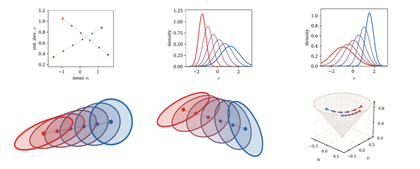

In [5]:
from pathlib import Path
from IPython.display import Image, display
_thumb = Path("thumbnails/monge-gaussian-w2-geodesic.png")
if not _thumb.exists():
    _thumb = Path("notebooks-figures/thumbnails/monge-gaussian-w2-geodesic.png")
display(Image(filename=str(_thumb)))
